# Bibliotecas y cofinguracion de graficos

In [173]:
import importlib
import subprocess
import sys

# Mapeo de imports → nombres reales de paquetes en pip
required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "seaborn": "seaborn",
    "statsmodels": "statsmodels",
    "sklearn": "scikit-learn",   
    "plotly": "plotly",
    "stargazer": "stargazer",
}

def safe_pip_install(package):
    """Instala un paquete si no está, sin actualizar."""
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", package],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )
        print(f"✓ {package} instalado correctamente.")
    except Exception:
        print(f"⚠ No se pudo instalar {package}. Puede estar bloqueado por Anaconda.")

def install_if_missing(import_name, pip_name):
    try:
        importlib.import_module(import_name)
        print(f"✔ {import_name} ya está instalado.")
    except ImportError:
        print(f"✖ {import_name} no está instalado. Instalando {pip_name}...")
        safe_pip_install(pip_name)

print("📦 Verificando librerías necesarias...\n")

for import_name, pip_name in required_packages.items():
    install_if_missing(import_name, pip_name)

print("\n🎉 Todas las librerías están listas.")


📦 Verificando librerías necesarias...

✔ numpy ya está instalado.
✔ pandas ya está instalado.
✔ matplotlib ya está instalado.
✔ scipy ya está instalado.
✔ seaborn ya está instalado.
✔ statsmodels ya está instalado.
✔ sklearn ya está instalado.
✔ plotly ya está instalado.
✔ stargazer ya está instalado.

🎉 Todas las librerías están listas.


In [174]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import scipy.stats as st
from scipy.stats import pointbiserialr
import seaborn as sns
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from scipy import stats
from IPython.core.display import display, HTML
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from IPython.display import clear_output, display
import warnings


In [175]:

warnings.filterwarnings("ignore")
PALETTE_NAME = "Accent"
HIST_GRAY = "0.38"  # histogr. en escala de grises (sin color de relleno)

sns.set_theme(style="whitegrid")
sns.set_palette(PALETTE_NAME)

plt.rc("font", size=12)
plt.rc("axes", titlesize=16, titleweight="bold")


def palette_n(n):
    # Colores discretos derivados de la paleta principal.
    n = max(int(n), 1)
    return sns.color_palette(PALETTE_NAME, n_colors=n)

# Limpieza de datos

In [176]:
df=pd.read_csv("data__movies.csv")
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4775 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   original_language     4803 non-null   object 
 5   original_title        4803 non-null   object 
 6   overview              4800 non-null   object 
 7   popularity            4803 non-null   float64
 8   production_companies  4452 non-null   object 
 9   release_date          4802 non-null   object 
 10  revenue               4803 non-null   int64  
 11  runtime               4801 non-null   float64
 12  status                4803 non-null   object 
 13  tagline               3959 non-null   object 
 14  title                 4803 non-null   object 
 15  vote_average         

## Limpieza de outlier y valores nulos

### contar outlier por columna

In [177]:
#contar outliers
def count_outliers(df):
    outlier_counts = {}
    for col in df.columns:

        if pd.api.types.is_numeric_dtype(df[col]):  # Solo columnas numéricas
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
            outlier_counts[col] = outliers
    outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier Count'])
    outlier_df = outlier_df.sort_values(by='Outlier Count', ascending=False)        
    return outlier_df

# Contar outliers en el DataFrame df
outlier_counts = count_outliers(df)
outlier_counts.head(20)

,Outlier Count
id,704
vote_count,504
revenue,472
budget,321
popularity,275
runtime,182
vote_average,156


### contar valores nulos

In [178]:
columnas = ["budget", "genres", "original_language", "popularity", "production_companies", "release_date", "revenue", "runtime", "vote_average", "vote_count"]

In [179]:
df1 = df[columnas]
df1["genres"].isna().sum()



28

In [180]:
#Dropeamos columnas NA en genres

df1 = df1.dropna(subset=['genres'])

### Limpieza de outliers en revenue
Limpiamos 0's, y el último cuantil

In [181]:
zero_revenue_count = (pd.to_numeric(df1['revenue'], errors='coerce') == 0).sum()
total_rows = len(df1)
print(f'Rows with revenue = 0: {zero_revenue_count}')
print(f'Percentage: {zero_revenue_count/total_rows:.2%}')
df1.drop(df1[pd.to_numeric(df1['revenue'], errors='coerce') == 0].index, inplace=True)

Rows with revenue = 0: 1400
Percentage: 29.32%


se pierde una cantidad sustancial de datos debido a eliminar ingresos nulos,si embargo estos datos no entregan informacion util sobre como se comportan los ingresos ya que al ser nulos lo unico que indican es que la pelicula probablemente no se estreno  

Revenue summary:
count    3.375000e+03
mean     1.170655e+08
std      1.834995e+08
min      5.000000e+00
25%      1.536924e+07
50%      5.180119e+07
75%      1.401684e+08
90%      3.028029e+08
95%      4.622882e+08
99%      9.021396e+08
max      2.787965e+09
Name: revenue, dtype: float64

--- Outlier Detection ---
Percentile 99 (Top 1%): > 902139643.72
Registros excluidos (Top 1%): 34
IQR bounds: [-171829511.0, 327367145.0]
IQR outliers: 299
Z-score outliers (|z|>3): 86

Top 15 highest Revenue:
        revenue
0    2787965087
25   1845034188
16   1519557910
28   1513528810
44   1506249360
7    1405403694
124  1274219009
31   1215439994
546  1156730962
26   1153304495
52   1123746996
329  1118888979
29   1108561013
36   1091405097
3    1084939099


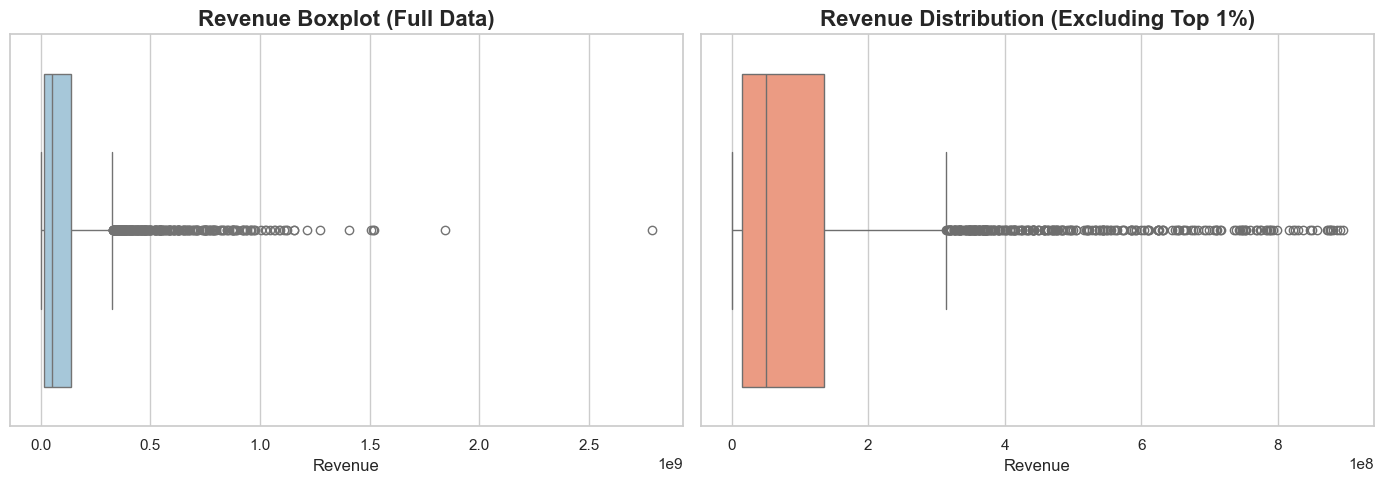

In [182]:
# 1. Limpieza de Revenue como numérico
revenue_clean = pd.to_numeric(df1['revenue'], errors='coerce')

# --- EXCLUSIÓN DEL ÚLTIMO 1% ---
q99 = revenue_clean.quantile(0.99)
outlier_99 = revenue_clean > q99

# 2. Método IQR
q1 = revenue_clean.quantile(0.25)
q3 = revenue_clean.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_iqr = (revenue_clean < lower) | (revenue_clean > upper)

# 3. Método Z-score (sobre valores no nulos)
mu = revenue_clean.mean()
sigma = revenue_clean.std()
z_scores = (revenue_clean - mu) / sigma
outlier_z = z_scores.abs() > 3

# --- IMPRESIÓN DE RESULTADOS ---
print('Revenue summary:')
print(revenue_clean.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

print('\n--- Outlier Detection ---')
print(f'Percentile 99 (Top 1%): > {round(q99, 2)}')
print(f'Registros excluidos (Top 1%): {int(outlier_99.sum())}')
print(f'IQR bounds: [{round(lower, 2)}, {round(upper, 2)}]')
print(f'IQR outliers: {int(outlier_iqr.sum())}')
print(f'Z-score outliers (|z|>3): {int(outlier_z.sum())}')

# Mostrar los 15 más altos
title_col = next((c for c in ['title', 'original_title', 'movie_title', 'name'] if c in df1.columns), None)
cols_to_show = ['revenue'] + ([title_col] if title_col else [])
print('\nTop 15 highest Revenue:')
print(df1.loc[revenue_clean.nlargest(15).index, cols_to_show])

# --- REVISIÓN VISUAL ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot original (con outliers)
sns.boxplot(x=revenue_clean.dropna(), ax=axes[0], color='#9ecae1')
axes[0].set_title('Revenue Boxplot (Full Data)')
axes[0].set_xlabel('Revenue')

# Boxplot sin outliers (excluyendo el último 1%)
revenue_no_outliers = revenue_clean[~outlier_99].dropna()  # ✅ Fix: variable separada
sns.boxplot(x=revenue_no_outliers, ax=axes[1], color='#fc9272')  # ✅ Fix: axes[1] en vez de axes[0]
axes[1].set_title('Revenue Distribution (Excluding Top 1%)')
axes[1].set_xlabel('Revenue')

plt.tight_layout()
plt.show()

notar que no existe un cambio sustancial en la distribucion de los datos al quitar el percentil 99 de estos,ademas se puede ver que los datos son muy dispersor entre si debido a su naturaleza,por lo tanto no se justifica eliminar estos outlier ya que podria aportar informacion sobre peliculas mega exitosas.

### limpieza de outlier en budget
Limpiamos 0's, y el último cuantil

In [183]:
zero_budget_count = (pd.to_numeric(df1['budget'], errors='coerce') == 0).sum()
total_rows = len(df1)
print(f'Rows with budget = 0: {zero_budget_count}')
print(f'Percentage: {zero_budget_count/total_rows:.2%}')
df1.drop(df1[pd.to_numeric(df1['budget'], errors='coerce') == 0].index, inplace=True)

Rows with budget = 0: 147
Percentage: 4.36%


mismo proceso que con revenue,notar que en este caso al ser poco datos nulos la perdida da filas informacion util es minima

Budget summary:
count    3.228000e+03
mean     4.066642e+07
std      4.439840e+07
min      1.000000e+00
25%      1.050000e+07
50%      2.500000e+07
75%      5.500000e+07
90%      9.500000e+07
95%      1.400000e+08
99%      2.000000e+08
max      3.800000e+08
Name: budget, dtype: float64

--- Outlier Detection for Budget ---
Percentile 99 (Top 1%): > 200000000.0
Registros excluidos (Top 1%): 27
IQR bounds: [-56250000.0, 121750000.0]
IQR outliers: 216
Z-score outliers (|z|>3): 76

Top 15 highest Budgets:
       budget
17  380000000
1   300000000
7   280000000
10  270000000
4   260000000
6   260000000
5   258000000
13  255000000
3   250000000
8   250000000
9   250000000
19  250000000
22  250000000
26  250000000
46  250000000


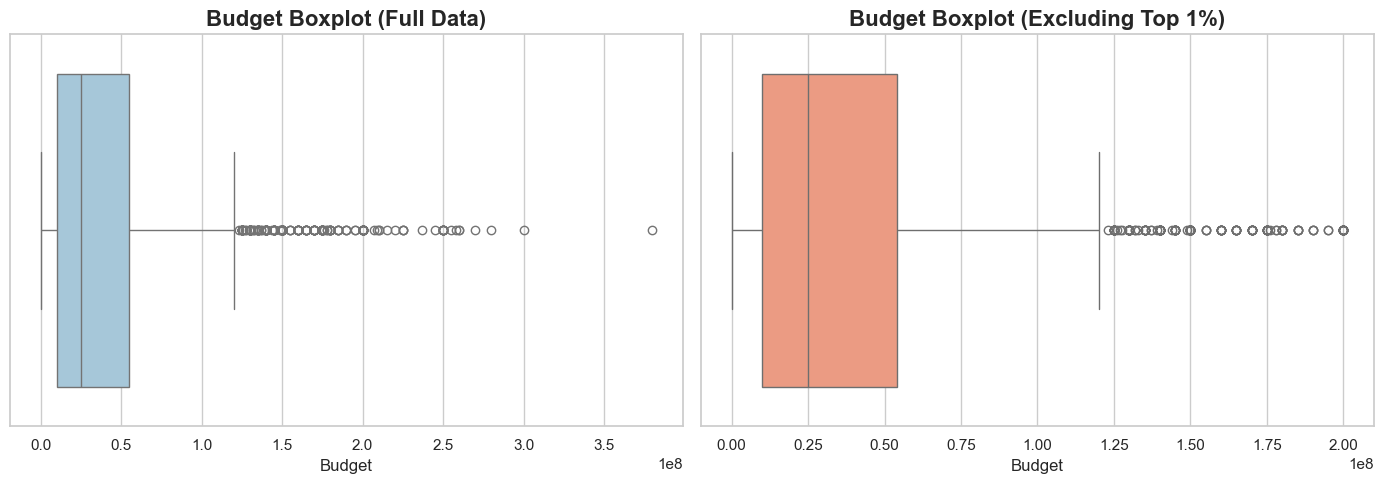

In [184]:
# 1. Limpieza de Budget como numérico
budget_clean = pd.to_numeric(df1['budget'], errors='coerce')

# --- EXCLUSIÓN DEL ÚLTIMO 1% (Percentil 99) ---
q99_budget = budget_clean.quantile(0.99)
outlier_99_budget = budget_clean > q99_budget

# 2. Método IQR
q1 = budget_clean.quantile(0.25)
q3 = budget_clean.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_iqr = (budget_clean < lower) | (budget_clean > upper)

# 3. Método Z-score (sobre valores no nulos)
mu = budget_clean.mean()
sigma = budget_clean.std()
z_scores = (budget_clean - mu) / sigma
outlier_z = z_scores.abs() > 3

# --- IMPRESIÓN DE RESULTADOS ---
print('Budget summary:')
print(budget_clean.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

print('\n--- Outlier Detection for Budget ---')
print(f'Percentile 99 (Top 1%): > {round(q99_budget, 2)}')
print(f'Registros excluidos (Top 1%): {int(outlier_99_budget.sum())}')
print(f'IQR bounds: [{round(lower, 2)}, {round(upper, 2)}]')
print(f'IQR outliers: {int(outlier_iqr.sum())}')
print(f'Z-score outliers (|z|>3): {int(outlier_z.sum())}')

# Mostrar los 15 presupuestos más altos
title_col = next((c for c in ['title', 'original_title', 'movie_title', 'name'] if c in df1.columns), None)
cols_to_show = ['budget'] + ([title_col] if title_col else [])
print('\nTop 15 highest Budgets:')
print(df1.loc[budget_clean.nlargest(15).index, cols_to_show])

# --- REVISIÓN VISUAL ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot original (con outliers)
sns.boxplot(x=budget_clean.dropna(), ax=axes[0], color='#9ecae1')  # ✅ Fix: .dropna()
axes[0].set_title('Budget Boxplot (Full Data)')
axes[0].set_xlabel('Budget')

# Boxplot sin outliers (excluyendo el último 1%)
budget_no_outliers = budget_clean[~outlier_99_budget].dropna()  # ✅ Fix: variable separada
sns.boxplot(x=budget_no_outliers, ax=axes[1], color='#fc9272')  # ✅ Fix: boxplot en vez de histplot
axes[1].set_title('Budget Boxplot (Excluding Top 1%)')
axes[1].set_xlabel('Budget')

plt.tight_layout()
plt.show()



denuevo se puede apreciar que la distribucion de revenue es bastante dispersa por lo que quitar outlier del percentil 99 podria eliminar informacion sobre mega produccion que puede ser util para el analisis,por lo tanto no se elimina.

## Encoding de variables categoricas

### clasificacion por lenguanje

*Hago one-hot en 'original language', 1 - Inglés, 0 - E.O.C*

In [185]:
df1["original_language"].value_counts()
df1["main_language_english"] = df1["original_language"].apply(lambda x: "1" if x == "en" else "0")


### Estudiamos el efecto del estudio y productora que produce las películas

In [186]:
df1["production_companies"].value_counts().head(30)

production_companies
Paramount Pictures                                                 48
Universal Pictures                                                 35
New Line Cinema                                                    29
Columbia Pictures                                                  28
Twentieth Century Fox Film Corporation                             25
Metro-Goldwyn-Mayer (MGM)                                          24
Warner Bros.                                                       24
Walt Disney Pictures                                               18
Touchstone Pictures                                                15
Columbia Pictures Corporation                                      13
Dimension Films                                                    13
DreamWorks Animation                                               12
Walt Disney Pictures, Pixar Animation Studios                      11
United Artists                                                     10

**Observamos que no existe una gran disparidad en la cantidad de películas realizadas por cada estudio, por lo tanto se estudiara si este comportarmiento se repite con las productoras**

In [187]:

studio_long = (
    df1[['production_companies']]
    .dropna()
    .assign(production_companies=lambda d: d['production_companies'].str.split(',\s*'))
    .explode('production_companies')
)

studio_long['production_companies'] = studio_long['production_companies'].str.strip()
studio_long = studio_long[studio_long['production_companies'] != '']

studio_counts = (
    studio_long['production_companies']
    .value_counts()
    .rename_axis('studio')
    .reset_index(name='total_movies')
)

studio_counts.head(30)

,studio,total_movies
0,Warner Bros.,280
1,Universal Pictures,273
2,Paramount Pictures,245
3,Twentieth Century Fox Film Corporation,201
4,Columbia Pictures,167
5,New Line Cinema,142
6,Relativity Media,100
7,Walt Disney Pictures,96
8,Touchstone Pictures,93
9,Metro-Goldwyn-Mayer (MGM),92


en este caso se aprecia que existe una gran diferencia entre el top 3 productoras y el resto.

### clasificacion por estudio famoso
Consideramos estudio famoso si cumple con 'total movies' > 90

In [188]:
studios_over_90 = set(studio_counts.loc[studio_counts['total_movies'] > 90, 'studio'])

def has_big_studio(companies):
    if pd.isna(companies):
        return 0
    studios = [s.strip() for s in str(companies).split(',') if s.strip()]
    return int(any(studio in studios_over_90 for studio in studios))

df1['big_studio'] = df1['production_companies'].apply(has_big_studio)
df1[['production_companies', 'big_studio']].head(10)

,production_companies,big_studio
0,"Ingenious Film Partners, Twentieth Century Fox...",1
1,"Walt Disney Pictures, Jerry Bruckheimer Films,...",1
2,"Columbia Pictures, Danjaq, B24",1
3,"Legendary Pictures, Warner Bros., DC Entertain...",1
4,Walt Disney Pictures,1
5,"Columbia Pictures, Laura Ziskin Productions, M...",1
6,"Walt Disney Pictures, Walt Disney Animation St...",1
7,"Marvel Studios, Prime Focus, Revolution Sun St...",0
8,"Warner Bros., Heyday Films",1
9,"DC Comics, Atlas Entertainment, Warner Bros., ...",1


In [189]:
df1["big_studio"].value_counts()

big_studio
0    1664
1    1564
Name: count, dtype: int64

### clasificacion de la columna de fechas

se separa la columna fechas para obterner mes,año,temporada y si el dias es laboral o no.

In [190]:
# Handle possible typo in column name
if 'release_date' in df1.columns:
    date_col = 'release_date'
elif 'relase_date' in df1.columns:
    date_col = 'relase_date'
else:
    raise KeyError("No release date column found. Expected 'release_date' or 'relase_date'.")

# 1) Standardize to datetime and YYYY-MM-DD
release_dt = pd.to_datetime(df1[date_col], errors='coerce')
df1['release_date_std'] = release_dt.dt.strftime('%Y-%m-%d')

# 2) Extract year
df1['release_year'] = release_dt.dt.year

# 3) Extract month name (e.g., October)
df1['release_month'] = release_dt.dt.month_name()

# 4) One-hot flag for business day
# Business day: Monday(0) to Friday(4)
df1['is_business_day_release'] = release_dt.dt.weekday.isin([0, 1, 2, 3, 4]).astype('Int64')

# 5) Season grouping based on month
# Northern Hemisphere seasons (United States)
# Winter:  Dec, Jan, Feb
# Spring:  Mar, Apr, May
# Summer:  Jun, Jul, Aug
# Fall:    Sep, Oct, Nov
def get_season(month):
    if pd.isna(month):
        return pd.NA
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return 'Other'

df1['release_season'] = release_dt.dt.month.map(get_season)

df1[[date_col, 'release_date_std', 'release_year', 'release_month', 'release_season', 'is_business_day_release']].head(10)

,release_date,release_date_std,release_year,release_month,release_season,is_business_day_release
0,2009-12-10,2009-12-10,2009,December,Winter,1
1,2007-05-19,2007-05-19,2007,May,Spring,0
2,2015-10-26,2015-10-26,2015,October,Fall,1
3,2012-07-16,2012-07-16,2012,July,Summer,1
4,2012-03-07,2012-03-07,2012,March,Spring,1
5,2007-05-01,2007-05-01,2007,May,Spring,1
6,2010-11-24,2010-11-24,2010,November,Fall,1
7,2015-04-22,2015-04-22,2015,April,Spring,1
8,2009-07-07,2009-07-07,2009,July,Summer,1
9,2016-03-23,2016-03-23,2016,March,Spring,1


### Clasificicacion por generos
one hot encoding de la colunna generos

In [191]:
df1['genres'].value_counts().head(30)

genres
Drama                                 204
Comedy                                197
Drama, Romance                         96
Comedy, Romance                        87
Comedy, Drama                          70
Comedy, Drama, Romance                 63
Horror, Thriller                       61
Horror                                 36
Drama, Thriller                        35
Action, Thriller                       32
Drama, History                         32
Crime, Drama, Thriller                 30
Action, Crime, Thriller                25
Adventure, Action, Thriller            24
Drama, Comedy                          24
Documentary                            22
Comedy, Crime                          22
Drama, Crime                           22
Comedy, Family                         21
Crime, Drama                           21
Animation, Family                      20
Action, Crime, Drama, Thriller         20
Drama, Comedy, Romance                 20
Animation, Comedy, Family  

In [192]:
genre_counts = (
    df['genres']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .loc[lambda s: s.ne('')]
    .value_counts()
)

genre_counts

genres
Drama              2297
Comedy             1722
Thriller           1274
Action             1154
Romance             894
Adventure           790
Crime               696
Science Fiction     535
Horror              519
Family              513
Fantasy             424
Mystery             348
Animation           234
History             197
Music               185
War                 144
Documentary         110
Western              82
Foreign              34
TV Movie              8
Name: count, dtype: int64

**Mapeamos los géneros y los agrupamos**

In [193]:
genre_map = {
    'science fiction': 'Fantasy',
    'thriller': 'Horror',
    'mystery': 'Crime',
    'music': 'Other',
    'war': 'Other',
    'documentary': 'Other',
    'western': 'Other',
    'foreign': 'Other',
    'tv movie': 'Other',
    'animation' : 'Family',
    'history' : 'Other'
}

genre_counts_generalized = (
    df['genres']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .loc[lambda s: s.ne('')]
    .map(lambda g: genre_map.get(g.lower(), g))
    .value_counts()
)


genre_counts_generalized


genres
Drama        2297
Horror       1793
Comedy       1722
Action       1154
Crime        1044
Fantasy       959
Romance       894
Adventure     790
Other         760
Family        747
Name: count, dtype: int64

In [194]:
#Ahora creamos una columna one-hot para cada género generalizado, asignando 1 si la película pertenece a ese género y 0 en caso contrario.
for genre in genre_counts_generalized.index:
    df1[f'genre_{genre}'] = df1['genres'].apply(
        lambda x: 1 if pd.notna(x) and genre in [
            genre_map.get(g.strip().lower(), g.strip())
            for g in x.split(',')
        ] else 0
    )
df1.head()

,budget,genres,original_language,popularity,production_companies,release_date,revenue,runtime,vote_average,vote_count,...,genre_Drama,genre_Horror,genre_Comedy,genre_Action,genre_Crime,genre_Fantasy,genre_Romance,genre_Adventure,genre_Other,genre_Family
0,237000000,"Action, Adventure, Fantasy, Science Fiction",en,150.437577,"Ingenious Film Partners, Twentieth Century Fox...",2009-12-10,2787965087,162.0,7.2,11800,...,0,0,0,1,0,1,0,1,0,0
1,300000000,"Adventure, Fantasy, Action",en,139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",2007-05-19,961000000,169.0,6.9,4500,...,0,0,0,1,0,1,0,1,0,0
2,245000000,"Action, Adventure, Crime",en,107.376788,"Columbia Pictures, Danjaq, B24",2015-10-26,880674609,148.0,6.3,4466,...,0,0,0,1,1,0,0,1,0,0
3,250000000,"Action, Crime, Drama, Thriller",en,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",2012-07-16,1084939099,165.0,7.6,9106,...,1,1,0,1,1,0,0,0,0,0
4,260000000,"Action, Adventure, Science Fiction",en,43.926995,Walt Disney Pictures,2012-03-07,284139100,132.0,6.1,2124,...,0,0,0,1,0,1,0,1,0,0


## Transformacion de variables

se trasformas variables con mucho outlier para mejorar su conportamiento sin la necesidad de perder datos

### estudio de budget

*Creamos Log-Budget*
log1p(budget) first: budget_log = log(1 + budget)

In [195]:
log_budget = np.log(1 + df1['budget'].dropna())
log_budget.describe()

count    3228.000000
mean       16.800614
std         1.661577
min         0.693147
25%        16.166886
50%        17.034386
75%        17.822844
max        19.755682
Name: budget, dtype: float64

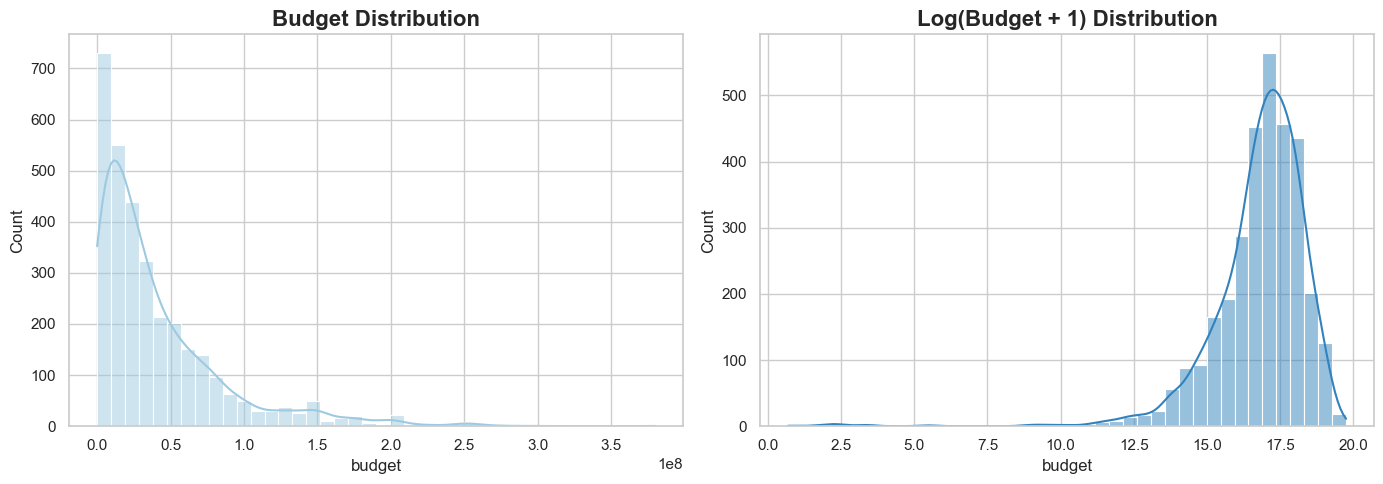

In [196]:
#Creamos un plot de budget y otro de budget logarítmico para comparar la distribución y detectar mejor los outliers.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df1['budget'].dropna(), bins=40, kde=True, ax=axes[0], color='#9ecae1')
axes[0].set_title('Budget Distribution')   
sns.histplot(log_budget, bins=40, kde=True, ax=axes[1], color='#3182bd')
axes[1].set_title('Log(Budget + 1) Distribution')
plt.tight_layout()
plt.show()  

In [197]:
#Ahora se puede observar que la distribución logarítmica es más simétrica y tiene menos outliers extremos, lo que facilita el análisis estadístico y la modelización. Usaremos standard scaler.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
log_budget_scaled = scaler.fit_transform(log_budget.values.reshape(-1, 1))
df1['log_budget_scaled'] = log_budget_scaled
df1.head()

,budget,genres,original_language,popularity,production_companies,release_date,revenue,runtime,vote_average,vote_count,...,genre_Horror,genre_Comedy,genre_Action,genre_Crime,genre_Fantasy,genre_Romance,genre_Adventure,genre_Other,genre_Family,log_budget_scaled
0,237000000,"Action, Adventure, Fantasy, Science Fiction",en,150.437577,"Ingenious Film Partners, Twentieth Century Fox...",2009-12-10,2787965087,162.0,7.2,11800,...,0,0,1,0,1,0,1,0,0,1.494570
1,300000000,"Adventure, Fantasy, Action",en,139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",2007-05-19,961000000,169.0,6.9,4500,...,0,0,1,0,1,0,1,0,0,1.636458
2,245000000,"Action, Adventure, Crime",en,107.376788,"Columbia Pictures, Danjaq, B24",2015-10-26,880674609,148.0,6.3,4466,...,0,0,1,1,0,0,1,0,0,1.514553
3,250000000,"Action, Crime, Drama, Thriller",en,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",2012-07-16,1084939099,165.0,7.6,9106,...,1,0,1,1,0,0,0,0,0,1.526713
4,260000000,"Action, Adventure, Science Fiction",en,43.926995,Walt Disney Pictures,2012-03-07,284139100,132.0,6.1,2124,...,0,0,1,0,1,0,1,0,0,1.550321


### estudiamos popularity

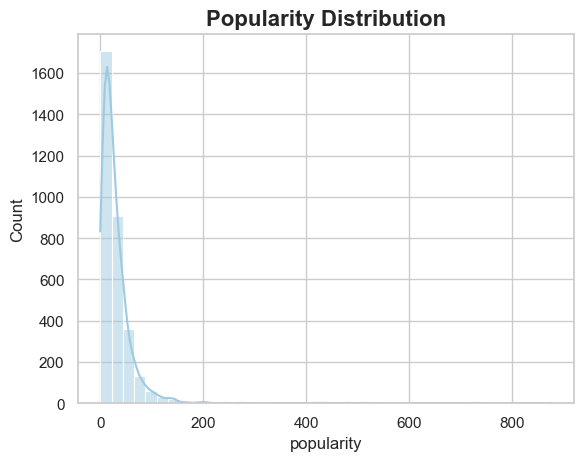

In [198]:
#Ploteamos la columna popularity para observar su distribución y detectar posibles outliers.
sns.histplot(df1['popularity'].dropna(), bins=40, kde=True, color='#9ecae1')
plt.title('Popularity Distribution')
plt.show()

In [199]:
#Aplicamos logaritmo a popularity para reducir la asimetría y facilitar el análisis estadístico.
log_popularity = np.log(1 + df1['popularity'].dropna())

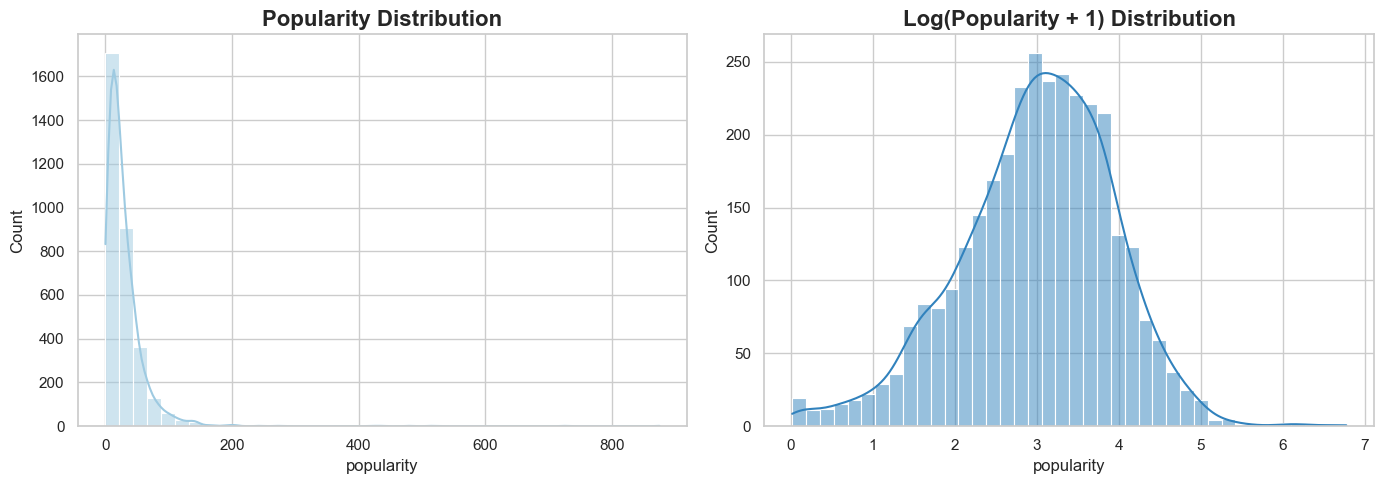

In [200]:
#Creamos un plot de popularity y otro de popularity logarítmico para comparar la distribución y detectar mejor los outliers.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df1['popularity'].dropna(), bins=40, kde=True, ax=axes[0], color='#9ecae1')
axes[0].set_title('Popularity Distribution')
sns.histplot(log_popularity, bins=40, kde=True, ax=axes[1], color='#3182bd')
axes[1].set_title('Log(Popularity + 1) Distribution')
plt.tight_layout()
plt.show()

In [201]:
#Aplicamos StandardScaler a popularity logarítmico para normalizarlo.
log_popularity_scaled = scaler.fit_transform(log_popularity.values.reshape(-1, 1))
df1["log_popularity_scaled"] = log_popularity_scaled
df1.head()

,budget,genres,original_language,popularity,production_companies,release_date,revenue,runtime,vote_average,vote_count,...,genre_Comedy,genre_Action,genre_Crime,genre_Fantasy,genre_Romance,genre_Adventure,genre_Other,genre_Family,log_budget_scaled,log_popularity_scaled
0,237000000,"Action, Adventure, Fantasy, Science Fiction",en,150.437577,"Ingenious Film Partners, Twentieth Century Fox...",2009-12-10,2787965087,162.0,7.2,11800,...,0,1,0,1,0,1,0,0,1.494570,2.159066
1,300000000,"Adventure, Fantasy, Action",en,139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",2007-05-19,961000000,169.0,6.9,4500,...,0,1,0,1,0,1,0,0,1.636458,2.075846
2,245000000,"Action, Adventure, Crime",en,107.376788,"Columbia Pictures, Danjaq, B24",2015-10-26,880674609,148.0,6.3,4466,...,0,1,1,0,0,1,0,0,1.514553,1.801847
3,250000000,"Action, Crime, Drama, Thriller",en,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",2012-07-16,1084939099,165.0,7.6,9106,...,0,1,1,0,0,0,0,0,1.526713,1.849404
4,260000000,"Action, Adventure, Science Fiction",en,43.926995,Walt Disney Pictures,2012-03-07,284139100,132.0,6.1,2124,...,0,1,0,1,0,1,0,0,1.550321,0.861632


### Estudiamos vote count

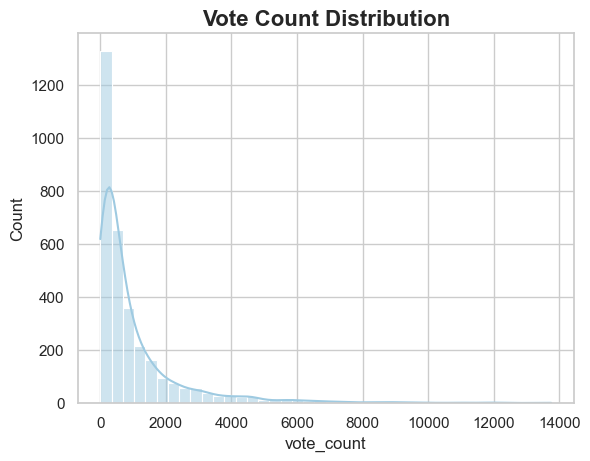

In [202]:
#Creamos un histograma de vote_count para observar su distribución y detectar posibles outliers.
sns.histplot(df1['vote_count'].dropna(), bins=40, kde=True, color='#9ecae1')
plt.title('Vote Count Distribution')
plt.show()

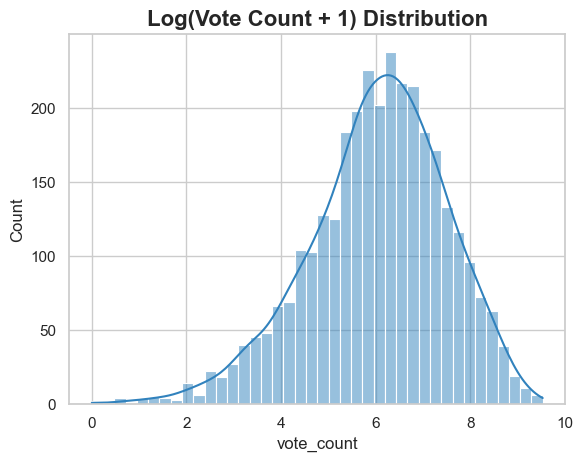

In [203]:
#Aplicamos logaritmo a vote_count para reducir la asimetría y facilitar el análisis estadístico.
log_vote_count = np.log(1 + df1['vote_count'].dropna())
#Revisamos el histograma de vote_count logarítmico para confirmar que la transformación ha reducido la asimetría y los outliers extremos.
sns.histplot(log_vote_count, bins=40, kde=True, color='#3182bd')
plt.title('Log(Vote Count + 1) Distribution')  
plt.show()

In [204]:
#Escalamos vote_count logarítmico con StandardScaler para normalizarlo.
log_vote_count_scaled = scaler.fit_transform(log_vote_count.values.reshape(-1, 1))
df1['log_vote_count_scaled'] = log_vote_count_scaled
df1.head()

,budget,genres,original_language,popularity,production_companies,release_date,revenue,runtime,vote_average,vote_count,...,genre_Action,genre_Crime,genre_Fantasy,genre_Romance,genre_Adventure,genre_Other,genre_Family,log_budget_scaled,log_popularity_scaled,log_vote_count_scaled
0,237000000,"Action, Adventure, Fantasy, Science Fiction",en,150.437577,"Ingenious Film Partners, Twentieth Century Fox...",2009-12-10,2787965087,162.0,7.2,11800,...,1,0,1,0,1,0,0,1.494570,2.159066,2.301360
1,300000000,"Adventure, Fantasy, Action",en,139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",2007-05-19,961000000,169.0,6.9,4500,...,1,0,1,0,1,0,0,1.636458,2.075846,1.637068
2,245000000,"Action, Adventure, Crime",en,107.376788,"Columbia Pictures, Danjaq, B24",2015-10-26,880674609,148.0,6.3,4466,...,1,1,0,0,1,0,0,1.514553,1.801847,1.631842
3,250000000,"Action, Crime, Drama, Thriller",en,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",2012-07-16,1084939099,165.0,7.6,9106,...,1,1,0,0,0,0,0,1.526713,1.849404,2.122765
4,260000000,"Action, Adventure, Science Fiction",en,43.926995,Walt Disney Pictures,2012-03-07,284139100,132.0,6.1,2124,...,1,0,1,0,1,0,0,1.550321,0.861632,1.119818


### Estudiamos Revenue

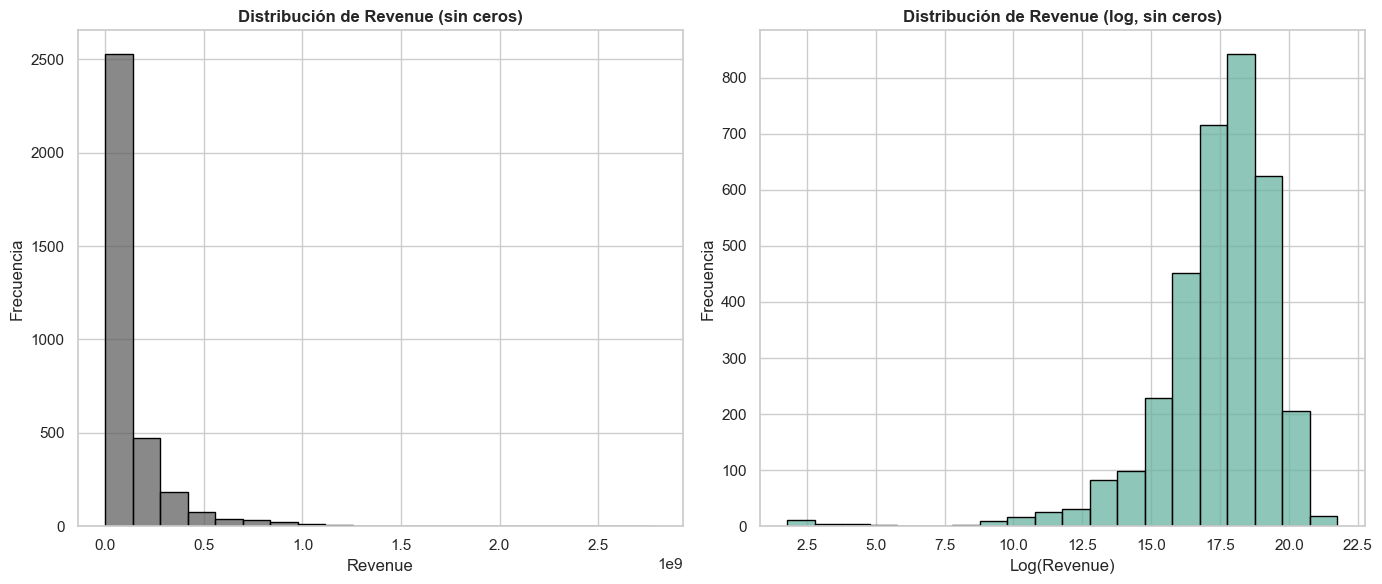

In [205]:
#Aplicamos logaritmo a revenue para reducir la asimetría y facilitar el análisis estadístico.
log_revenue = np.log(1 + df1['revenue'].dropna())

sns.set_theme(style="whitegrid")

#  Filtrar ceros
df_sin_ceros = df[df["revenue"] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# 📊 Histograma normal (sin ceros)
sns.histplot(
    df_sin_ceros["revenue"],
    bins=20,
    color="0.38",
    edgecolor="black",
    ax=axes[0]
)

axes[0].set_title("Distribución de Revenue (sin ceros)")
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("Frecuencia")

# 📊 Histograma log (sin ceros)
sns.histplot(
    np.log1p(df_sin_ceros["revenue"]),
    bins=20,
    color="#69b3a2",
    edgecolor="black",
    ax=axes[1]
)

axes[1].set_title("Distribución de Revenue (log, sin ceros)")
axes[1].set_xlabel("Log(Revenue)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()

plt.show()

In [206]:
df1["log_revenue"] = log_revenue
df1.head()

,budget,genres,original_language,popularity,production_companies,release_date,revenue,runtime,vote_average,vote_count,...,genre_Crime,genre_Fantasy,genre_Romance,genre_Adventure,genre_Other,genre_Family,log_budget_scaled,log_popularity_scaled,log_vote_count_scaled,log_revenue
0,237000000,"Action, Adventure, Fantasy, Science Fiction",en,150.437577,"Ingenious Film Partners, Twentieth Century Fox...",2009-12-10,2787965087,162.0,7.2,11800,...,0,1,0,1,0,0,1.494570,2.159066,2.301360,21.748578
1,300000000,"Adventure, Fantasy, Action",en,139.082615,"Walt Disney Pictures, Jerry Bruckheimer Films,...",2007-05-19,961000000,169.0,6.9,4500,...,0,1,0,1,0,0,1.636458,2.075846,1.637068,20.683485
2,245000000,"Action, Adventure, Crime",en,107.376788,"Columbia Pictures, Danjaq, B24",2015-10-26,880674609,148.0,6.3,4466,...,1,0,0,1,0,0,1.514553,1.801847,1.631842,20.596199
3,250000000,"Action, Crime, Drama, Thriller",en,112.312950,"Legendary Pictures, Warner Bros., DC Entertain...",2012-07-16,1084939099,165.0,7.6,9106,...,1,0,0,0,0,0,1.526713,1.849404,2.122765,20.804790
4,260000000,"Action, Adventure, Science Fiction",en,43.926995,Walt Disney Pictures,2012-03-07,284139100,132.0,6.1,2124,...,0,1,0,1,0,0,1.550321,0.861632,1.119818,19.464974


# estadistica descriptiva

## Estudio ROI

### Estudio ROI y ingresos por inversion realizada

In [207]:
#Create a ROI column as (Revenue - Budget) / Budget
df1['ROI'] = (df1['revenue'] - df1['budget']) / df1['budget']
#Create 10 quantiles for ROI column
df1['ROI_quantile'] = pd.qcut(df1['ROI'], 10, labels=False)
df1[['revenue', 'budget', 'ROI']].tail(10)


,revenue,budget,ROI
4738,3221152,60000,52.685867
4742,28575078,65000,438.616585
4752,416498,65000,5.407662
4758,600896,4000000,-0.849776
4772,10000,31192,-0.679405
4773,3151130,27000,115.708519
4788,6000000,12000,499.000000
4792,99000,20000,3.950000
4796,424760,7000,59.680000
4798,2040920,220000,8.276909


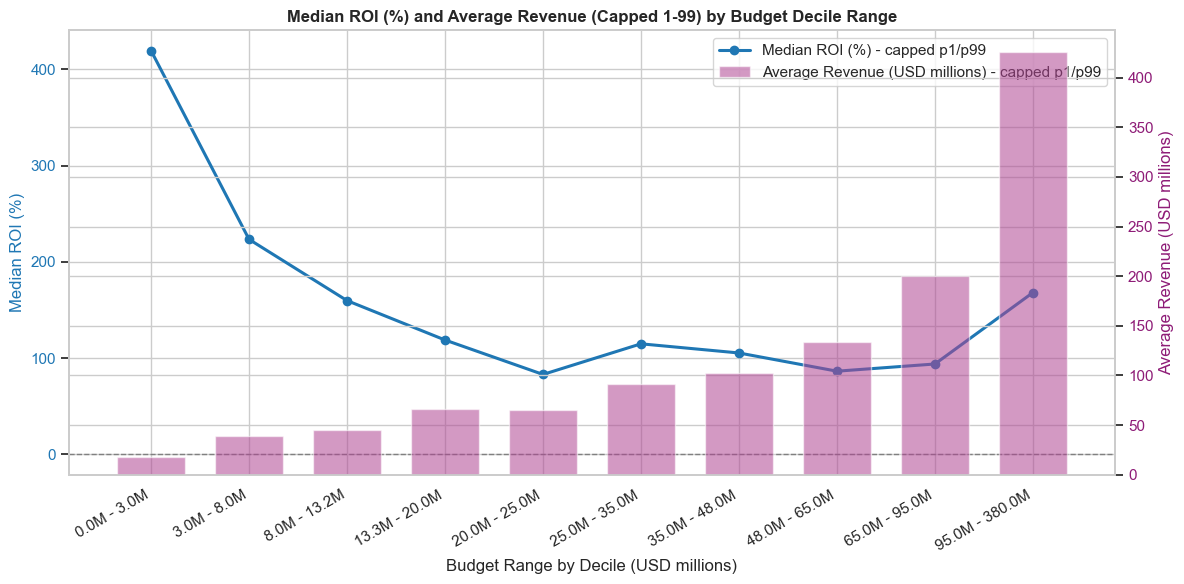

In [208]:
# Plot principal: ROI (%) y revenue promedio por deciles de presupuesto
plot_df = df1[['budget', 'revenue']].copy()
plot_df = plot_df[(plot_df['budget'] > 0) & (plot_df['revenue'] >= 0)]

# ROI en porcentaje
plot_df['ROI_pct'] = ((plot_df['revenue'] - plot_df['budget']) / plot_df['budget']) * 100

# Cap 1-99 percentil para reducir sesgo por extremos (ROI y Revenue)
roi_p1 = plot_df['ROI_pct'].quantile(0.01)
roi_p99 = plot_df['ROI_pct'].quantile(0.99)
plot_df['ROI_pct_capped'] = plot_df['ROI_pct'].clip(lower=roi_p1, upper=roi_p99)

rev_p1 = plot_df['revenue'].quantile(0.01)
rev_p99 = plot_df['revenue'].quantile(0.99)
plot_df['revenue_capped'] = plot_df['revenue'].clip(lower=rev_p1, upper=rev_p99)

# Deciles 1-10 garantizados usando ranking
plot_df['budget_decile'] = pd.qcut(
    plot_df['budget'].rank(method='first'),
    q=10,
    labels=range(1, 11)
).astype(int)

# Resumen por decil: mediana ROI capeada, revenue promedio capeado y extremos de budget
summary_decile = (
    plot_df.groupby('budget_decile', as_index=False)
    .agg(
        median_roi_pct=('ROI_pct_capped', 'median'),
        avg_revenue=('revenue_capped', 'mean'),
        budget_min=('budget', 'min'),
        budget_max=('budget', 'max')
    )
    .sort_values('budget_decile')
)

# Revenue en millones para escala legible
summary_decile['avg_revenue_m'] = summary_decile['avg_revenue'] / 1_000_000

# Etiquetas del eje X con extremos de cada decil
summary_decile['budget_range_label'] = (
    (summary_decile['budget_min'] / 1_000_000).round(1).astype(str)
    + 'M - '
    + (summary_decile['budget_max'] / 1_000_000).round(1).astype(str)
    + 'M'
)

x_pos = np.arange(len(summary_decile))

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Barras: revenue promedio capeado (eje derecho)
ax2.bar(
    x_pos,
    summary_decile['avg_revenue_m'],
    color="#af4593",
    alpha=0.55,
    width=0.7,
    label='Average Revenue (USD millions) - capped p1/p99'
)

# Línea: mediana ROI % capeada (eje izquierdo)
ax1.plot(
    x_pos,
    summary_decile['median_roi_pct'],
    marker='o',
    linewidth=2.2,
    color='#1f77b4',
    label='Median ROI (%) - capped p1/p99'
)

# Ejes y formato
ax1.set_xlabel('Budget Range by Decile (USD millions)')
ax1.set_ylabel('Median ROI (%)', color='#1f77b4')
ax2.set_ylabel('Average Revenue (USD millions)', color="#8e1c77")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(summary_decile['budget_range_label'], rotation=30, ha='right')
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax2.tick_params(axis='y', labelcolor="#8e1c77")
ax1.set_title('Median ROI (%) and Average Revenue (Capped 1-99) by Budget Decile Range')

# Leyenda combinada
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='best', frameon=True)

plt.tight_layout()
plt.show()

**Interpretación gráfico**

A medida que se invierte más budget en las películas, se esperan porcentajes de retornos a la inversión menores, sin embargo, ingresos mayores, que representan mayor utilidad.

### Estudio ROI por género

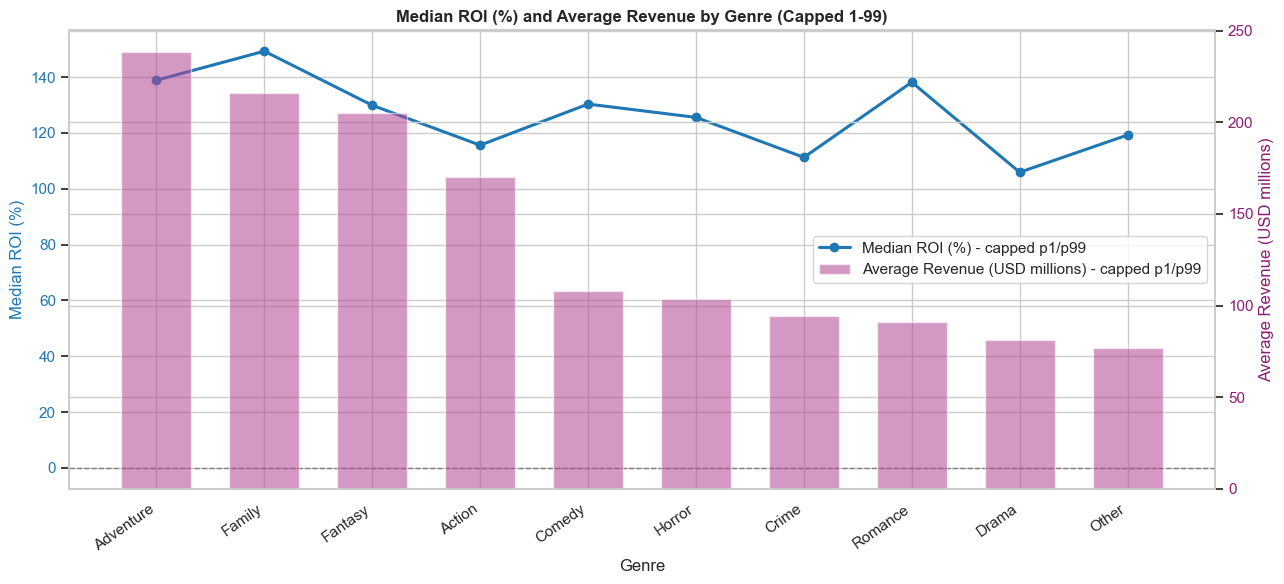

In [209]:
# Median ROI (%) and Avg Revenue by Genre (same capped 1-99 logic)
genre_cols = [c for c in df1.columns if c.startswith('genre_')]

# Base table with needed numeric fields
plot_df = df1[['budget', 'revenue'] + genre_cols].copy()
plot_df = plot_df[(plot_df['budget'] > 0) & (plot_df['revenue'] >= 0)]

# ROI in percentage
plot_df['ROI_pct'] = ((plot_df['revenue'] - plot_df['budget']) / plot_df['budget']) * 100

# Cap 1-99 percentile for both metrics
roi_p1 = plot_df['ROI_pct'].quantile(0.01)
roi_p99 = plot_df['ROI_pct'].quantile(0.99)
plot_df['ROI_pct_capped'] = plot_df['ROI_pct'].clip(lower=roi_p1, upper=roi_p99)

rev_p1 = plot_df['revenue'].quantile(0.01)
rev_p99 = plot_df['revenue'].quantile(0.99)
plot_df['revenue_capped'] = plot_df['revenue'].clip(lower=rev_p1, upper=rev_p99)

# Compute metrics per genre using one-hot membership
rows = []
for g in genre_cols:
    mask = plot_df[g] == 1
    if mask.any():
        rows.append({
            'genre': g.replace('genre_', ''),
            'median_roi_pct': plot_df.loc[mask, 'ROI_pct_capped'].median(),
            'avg_revenue_m': plot_df.loc[mask, 'revenue_capped'].mean() / 1_000_000,
            'n_movies': int(mask.sum())
        })

genre_summary = pd.DataFrame(rows).sort_values('avg_revenue_m', ascending=False).reset_index(drop=True)

# Plot with twin y-axes: ROI as line, revenue as bars
x_pos = np.arange(len(genre_summary))

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

# Bars for average revenue (right axis)
ax2.bar(
    x_pos,
    genre_summary['avg_revenue_m'],
    width=0.65,
    color='#af4593',
    alpha=0.55,
    label='Average Revenue (USD millions) - capped p1/p99'
 )

# Line for median ROI (left axis)
ax1.plot(
    x_pos,
    genre_summary['median_roi_pct'],
    marker='o',
    linewidth=2.2,
    color='#1f77b4',
    label='Median ROI (%) - capped p1/p99'
 )

ax1.set_xlabel('Genre')
ax1.set_ylabel('Median ROI (%)', color='#1f77b4')
ax2.set_ylabel('Average Revenue (USD millions)', color='#8e1c77')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(genre_summary['genre'], rotation=35, ha='right')
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax2.tick_params(axis='y', labelcolor='#8e1c77')
ax1.set_title('Median ROI (%) and Average Revenue by Genre (Capped 1-99)')

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='best', frameon=True)

plt.tight_layout()
plt.show()

### Estudio ROI por temporada

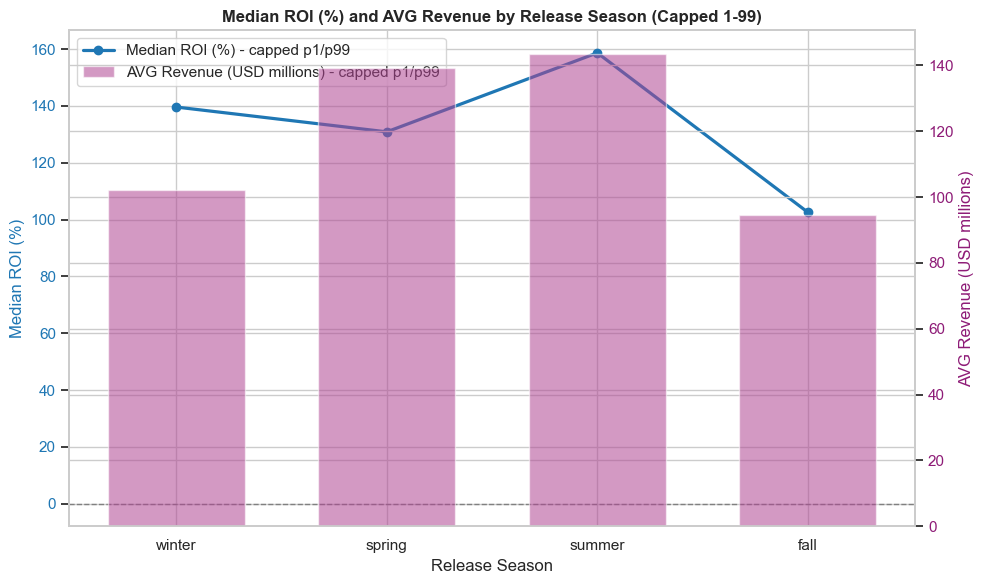

In [210]:
# Median ROI (%) and Avg Revenue by release season
season_order = ['Winter', 'Spring', 'Summer', 'Fall']

# Base table
plot_df = df1[['release_season', 'budget', 'revenue']].copy()
plot_df = plot_df[
    (plot_df['budget'] > 0)
    & (plot_df['revenue'] >= 0)
    & (plot_df['release_season'].isin(season_order))
]

# ROI in percentage
plot_df['ROI_pct'] = ((plot_df['revenue'] - plot_df['budget']) / plot_df['budget']) * 100

# Cap 1-99 percentile for both metrics
roi_p1 = plot_df['ROI_pct'].quantile(0.01)
roi_p99 = plot_df['ROI_pct'].quantile(0.99)
plot_df['ROI_pct_capped'] = plot_df['ROI_pct'].clip(lower=roi_p1, upper=roi_p99)

rev_p1 = plot_df['revenue'].quantile(0.01)
rev_p99 = plot_df['revenue'].quantile(0.99)
plot_df['revenue_capped'] = plot_df['revenue'].clip(lower=rev_p1, upper=rev_p99)

# Aggregate by season in fixed order
season_summary = (
    plot_df.groupby('release_season', as_index=False)
    .agg(
        median_roi_pct=('ROI_pct_capped', 'median'),
        avg_revenue=('revenue_capped', 'mean')
    )
)
season_summary['release_season'] = pd.Categorical(
    season_summary['release_season'],
    categories=season_order,
    ordered=True
)
season_summary = season_summary.sort_values('release_season')
season_summary['avg_revenue_m'] = season_summary['avg_revenue'] / 1_000_000

x_pos = np.arange(len(season_summary))

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Bars: average revenue (right axis)
ax2.bar(
    x_pos,
    season_summary['avg_revenue_m'],
    color='#af4593',
    alpha=0.55,
    width=0.65,
    label='AVG Revenue (USD millions) - capped p1/p99'
)

# Line: median ROI (left axis)
ax1.plot(
    x_pos,
    season_summary['median_roi_pct'],
    marker='o',
    linewidth=2.3,
    color='#1f77b4',
    label='Median ROI (%) - capped p1/p99'
)

# Axes formatting
ax1.set_xlabel('Release Season')
ax1.set_ylabel('Median ROI (%)', color='#1f77b4')
ax2.set_ylabel('AVG Revenue (USD millions)', color='#8e1c77')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(['winter', 'spring', 'summer', 'fall'])
ax1.axhline(0, color='gray', linestyle='--', linewidth=1)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax2.tick_params(axis='y', labelcolor='#8e1c77')
ax1.set_title('Median ROI (%) and AVG Revenue by Release Season (Capped 1-99)')

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

## Grafico de generos con mayores revenues

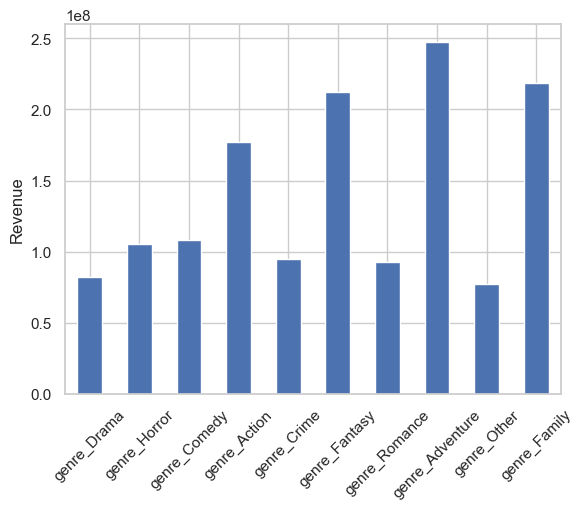

In [211]:
import pandas as pd
import matplotlib.pyplot as plt

genre_cols = [col for col in df1.columns if col.startswith('genre_')]

revenues = {g: df1[df1[g]==1]['revenue'].mean() for g in genre_cols}

pd.Series(revenues).plot(kind='bar')

plt.xticks(rotation=45)
plt.ylabel('Revenue')
plt.show()

## Grafico de revenue segun temporada de lanzamiento

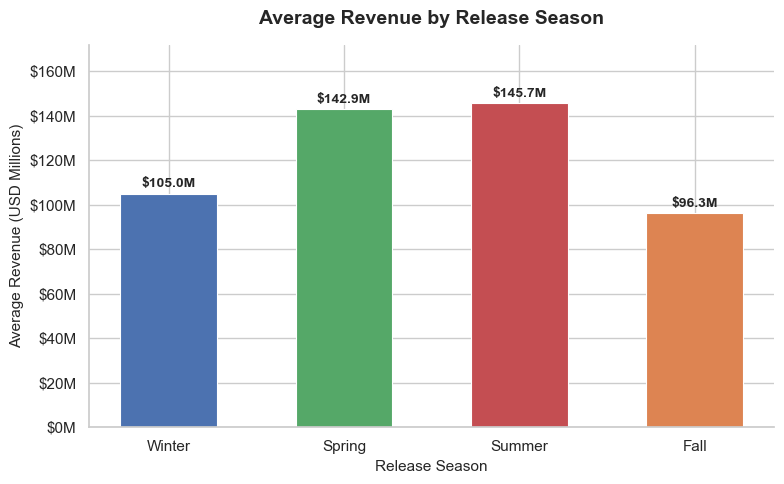

In [212]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Aggregate: mean revenue per season ────────────────────────────────────
season_order = ['Winter', 'Spring', 'Summer', 'Fall']

season_revenue = (
    df1[df1['revenue'] > 0]          # excluir películas sin revenue
    .groupby('release_season')['revenue']
    .mean()
    .reindex(season_order)            # orden cronológico
    .reset_index()
)
season_revenue.columns = ['release_season', 'avg_revenue']

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#4C72B0', '#55A868', '#C44E52', '#DD8452']

bars = ax.bar(
    season_revenue['release_season'],
    season_revenue['avg_revenue'] / 1e6,   # en millones
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.55
)

# Etiquetas encima de cada barra
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.5,
        f'${height:,.1f}M',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

ax.set_title('Average Revenue by Release Season', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Release Season', fontsize=11)
ax.set_ylabel('Average Revenue (USD Millions)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
ax.set_ylim(0, season_revenue['avg_revenue'].max() / 1e6 * 1.18)
sns.despine()

plt.tight_layout()
plt.show()

In [213]:
df1.columns

Index(['budget', 'genres', 'original_language', 'popularity',
       'production_companies', 'release_date', 'revenue', 'runtime',
       'vote_average', 'vote_count', 'main_language_english', 'big_studio',
       'release_date_std', 'release_year', 'release_month',
       'is_business_day_release', 'release_season', 'genre_Drama',
       'genre_Horror', 'genre_Comedy', 'genre_Action', 'genre_Crime',
       'genre_Fantasy', 'genre_Romance', 'genre_Adventure', 'genre_Other',
       'genre_Family', 'log_budget_scaled', 'log_popularity_scaled',
       'log_vote_count_scaled', 'log_revenue', 'ROI', 'ROI_quantile'],
      dtype='object')

In [214]:
columnas_utiles=['log_revenue',"log_budget_scaled",'release_year', 'release_month',
       'is_business_day_release', 'genre_Drama', 'genre_Horror',
       'genre_Comedy', 'genre_Action', 'genre_Crime', 'genre_Fantasy',
       'genre_Romance', 'genre_Adventure', 'genre_Family', 'genre_Other','big_studio','log_popularity_scaled','vote_average','main_language_english',"release_season"]

data=df1[columnas_utiles]

## matriz de correlacion

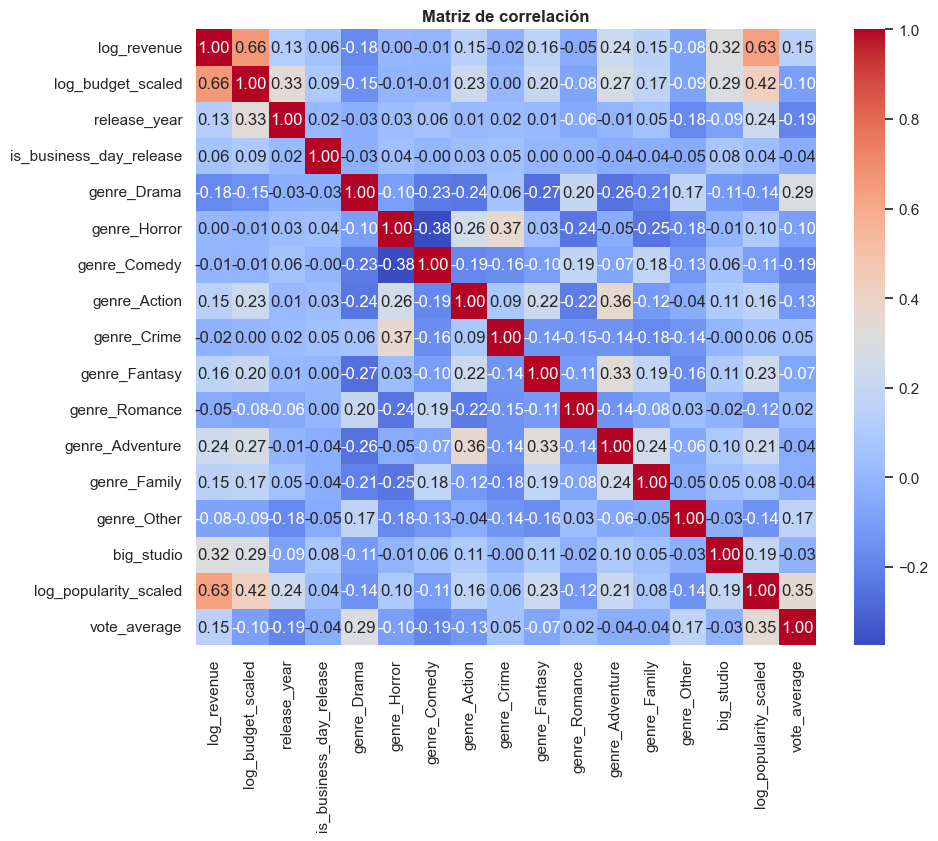

In [215]:


def heatmap_corr(df):
    corr = df.select_dtypes(include='number').corr()
    
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    
    plt.title('Matriz de correlación')
    plt.show()
heatmap_corr(data)    

## graficos de dispersion

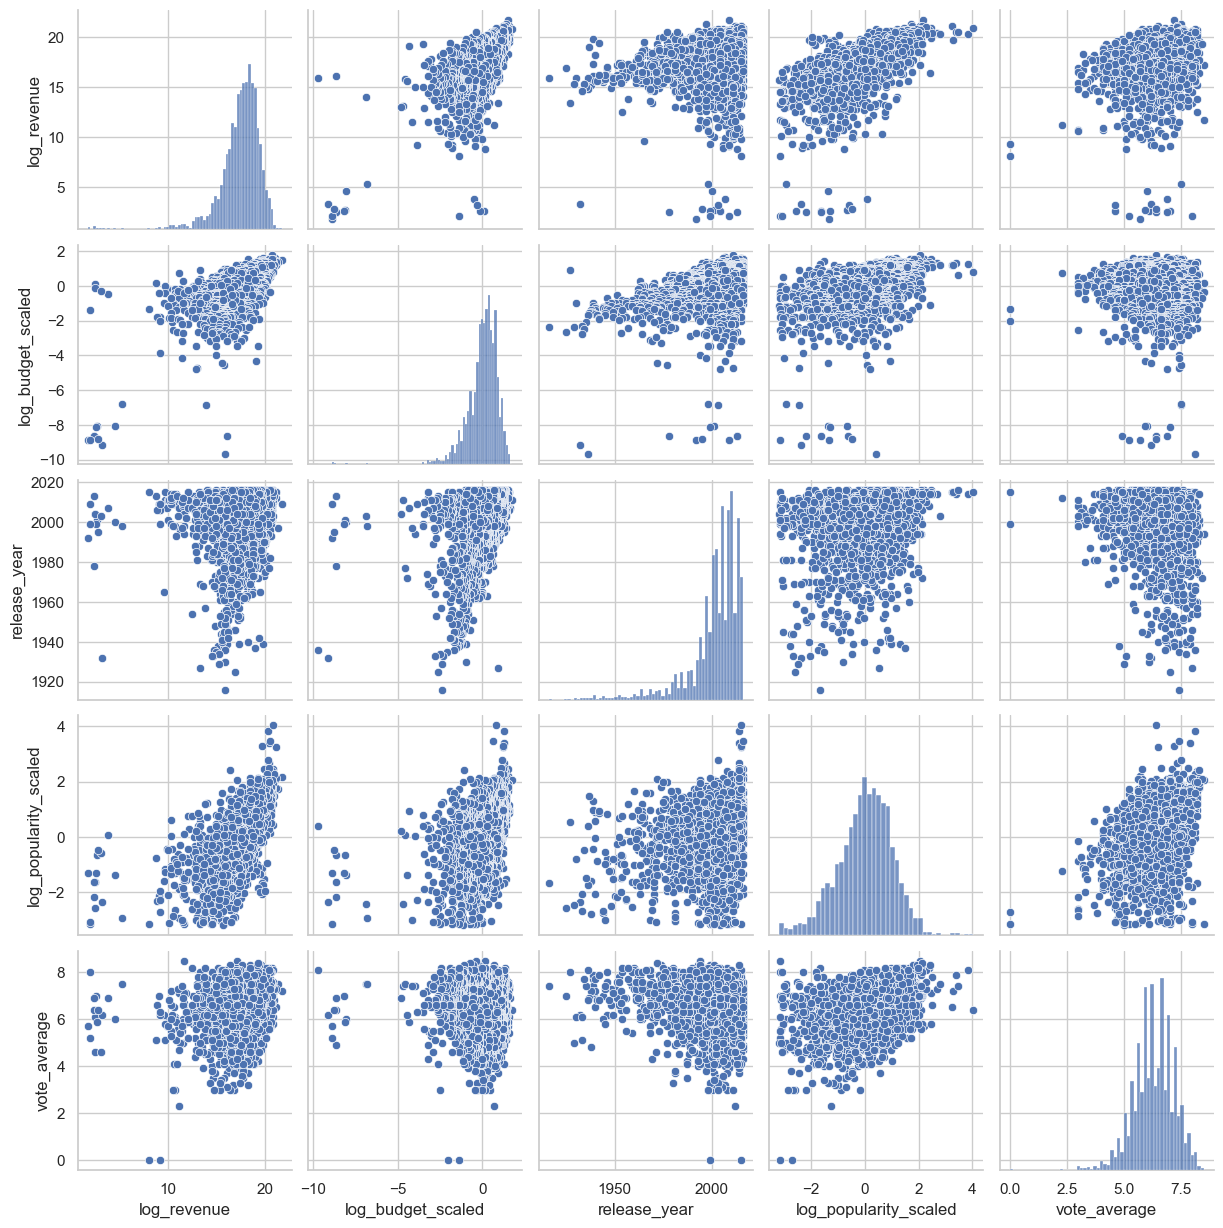

In [216]:
sns.pairplot(data.select_dtypes(include='number').loc[:, data.select_dtypes(include='number').nunique() > 2])

# Regresion multivariada

In [217]:
data.columns

Index(['log_revenue', 'log_budget_scaled', 'release_year', 'release_month',
       'is_business_day_release', 'genre_Drama', 'genre_Horror',
       'genre_Comedy', 'genre_Action', 'genre_Crime', 'genre_Fantasy',
       'genre_Romance', 'genre_Adventure', 'genre_Family', 'genre_Other',
       'big_studio', 'log_popularity_scaled', 'vote_average',
       'main_language_english', 'release_season'],
      dtype='object')

In [218]:
data["interaccion_1"]=data["release_year"]*data["genre_Drama"]
data["interaccion_2"]=data["release_year"]*data["genre_Action"] #0.135
data["interaccion_3"]=data["release_year"]*data["genre_Crime"]  #0.049
data["interaccion_4"]=data["release_year"]*data["genre_Fantasy"] #0.614
data["interaccion_5"]=data["release_year"]*data["genre_Romance"] #
data["interaccion_6"]=data["release_year"]*data["genre_Adventure"]
data["interaccion_7"]=data["release_year"]*data["genre_Family"] #0.429
data["interaccion_9"]=data["release_year"]*data["genre_Other"]  #0.915


In [219]:
data.columns

Index(['log_revenue', 'log_budget_scaled', 'release_year', 'release_month',
       'is_business_day_release', 'genre_Drama', 'genre_Horror',
       'genre_Comedy', 'genre_Action', 'genre_Crime', 'genre_Fantasy',
       'genre_Romance', 'genre_Adventure', 'genre_Family', 'genre_Other',
       'big_studio', 'log_popularity_scaled', 'vote_average',
       'main_language_english', 'release_season', 'interaccion_1',
       'interaccion_2', 'interaccion_3', 'interaccion_4', 'interaccion_5',
       'interaccion_6', 'interaccion_7', 'interaccion_9'],
      dtype='object')

## resultado

In [220]:
data['log_budget_scaled_sq'] = data['log_budget_scaled']**2
resultado4 = smf.ols('log_revenue ~log_popularity_scaled+vote_average+interaccion_1+interaccion_5+interaccion_6+log_budget_scaled+log_budget_scaled_sq+genre_Drama+big_studio+genre_Drama+genre_Horror+genre_Comedy+genre_Action+genre_Crime+genre_Fantasy+genre_Romance+genre_Adventure+genre_Family+genre_Other+C(release_season)' , data=data).fit() 
print(resultado4.summary())

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     252.6
Date:               sáb, 25 abr. 2026   Prob (F-statistic):               0.00
Time:                        11:50:41   Log-Likelihood:                -5365.7
No. Observations:                3228   AIC:                         1.078e+04
Df Residuals:                    3206   BIC:                         1.091e+04
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

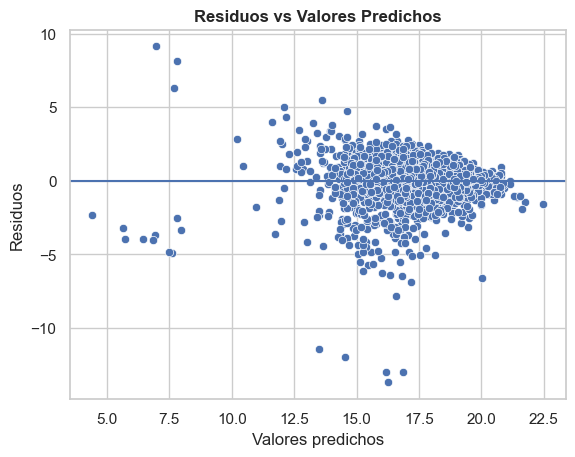

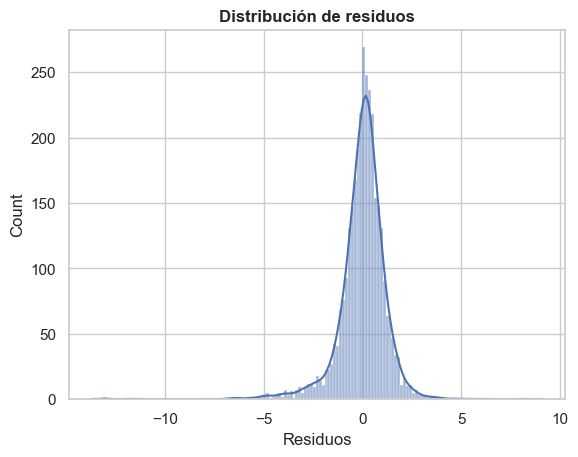

<Figure size 640x480 with 0 Axes>

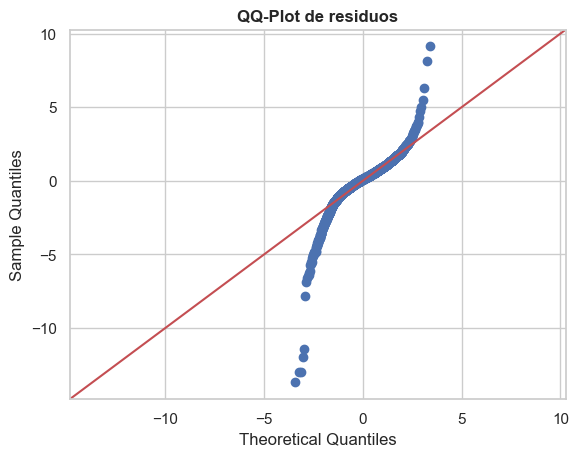

In [221]:
# Predicciones (IMPORTANTE: usar el mismo DataFrame)
y_pred = resultado4.predict(data)

# Residuos
residuos = data['log_revenue'] - y_pred

# -------------------------------
# 1. Residuos vs valores predichos
# -------------------------------
plt.figure()
sns.scatterplot(x=y_pred, y=residuos)
plt.axhline(0)
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs Valores Predichos")
plt.show()

# -------------------------------
# 2. Histograma de residuos
# -------------------------------
plt.figure()
sns.histplot(residuos, kde=True)
plt.xlabel("Residuos")
plt.title("Distribución de residuos")
plt.show()

# -------------------------------
# 3. QQ-plot (normalidad)
# -------------------------------
import statsmodels.api as sm

plt.figure()
sm.qqplot(residuos, line='45')
plt.title("QQ-Plot de residuos")
plt.show()

# Analisis de resultados


-vote avg tiene mayor corr con la polularidad que del revenue,por lo tanto se puede decir que en general las votaciones sirven para medir la popularidad de una pelicula que su exito en taquilla.


-el presupuesto y la popularidad estan altamente relacionados postivamente lo que nos indica que las peliculas mas populares en general suelen tener altos presupuestos

-el presupuesto tiene rendimientos decrecientes respecto a las ganancias que genera,esto nos indica que a medida que aumenta la inversion en una pelicula su ganancias aumentan,pero cada vez es mas dificil obtener ganancias proporcionales a una alta inversion,es decir el ROI de peliculas con alta inversion es menor que el de peliculas con poca inversion

-la regresion indica que la epoca que tiene mayor impacto en las ganancias de una pelicula es en verano,en donde el simple hecho de lanzarla en esta fecha y no otra puede generar un aumento del 17.43 % respecto al resto de epocas del año.

-segun la regresion los generos mas rentables son los de drama,romance y aventura y el menos rentable es el de fantasia (lo de la fantasia puede ser porque en general esas gastan mucha plata en efectos especiales y weas,en cambio las de romance son mas baratas de hacer (creo))

-que una pelicula sea pruducida por un estudio grande o no tiene un efecto muy grande sobre sus ganancias,en particulas,las peliculas producidas por estudios grande generar un 48.482% mas de ganancias que las producidas por nonames.